## Parte 5 — Análise com e sem PCA

### Observação sobre o uso de PCA

É importante destacar que o dataset utilizado já passou por um processo de transformação utilizando PCA, resultando nas variáveis V1 a V28.

Dessa forma, a aplicação adicional de PCA nesta etapa tem caráter experimental, com o objetivo de analisar o impacto da redução de dimensionalidade no desempenho dos modelos, e não como uma necessidade de pré-processamento dos dados.

1. Importação de bibliotecas

In [2]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

2. Carregamento dos dados

In [3]:
df = pd.read_csv('../data/creditcard.csv')

X = df.drop('Class', axis=1)
y = df['Class']

3. Aplicação do PCA

In [4]:
pca = PCA(n_components=10)

X_pca = pca.fit_transform(X)

### Aplicação de PCA

Nesta etapa, aplicamos PCA para reduzir a dimensionalidade dos dados, mantendo apenas os 10 principais componentes.
O objetivo é analisar como a redução de informação impacta o desempenho dos modelos.

4. Divisão treino/teste

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

5. Regressão Logística com PCA

In [6]:
model_pca = LogisticRegression(max_iter=1000, class_weight='balanced')

model_pca.fit(X_train, y_train)

y_pred_pca = model_pca.predict(X_test)

Matriz de confusão

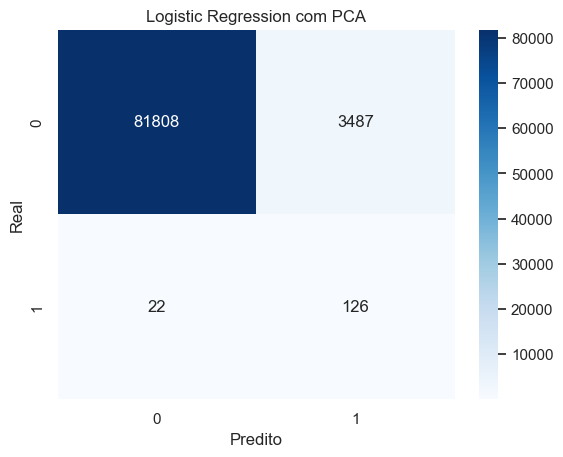

In [7]:
cm_pca = confusion_matrix(y_test, y_pred_pca)

sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression com PCA')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

6. Isolation Forest com PCA

In [8]:
model_if_pca = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)

model_if_pca.fit(X_pca)

y_pred_if_pca = model_if_pca.predict(X_pca)
y_pred_if_pca = np.where(y_pred_if_pca == -1, 1, 0)

Matriz de confusão

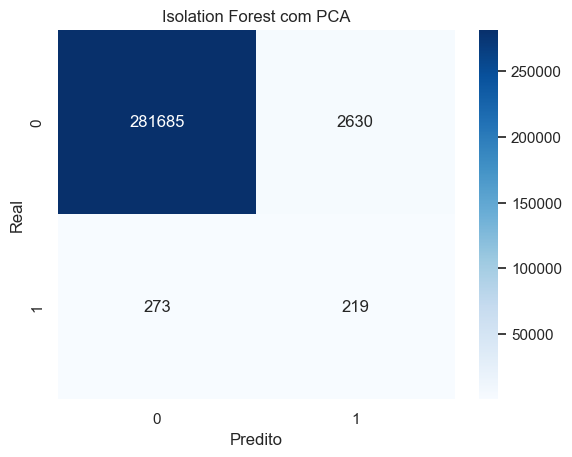

In [9]:
cm_if_pca = confusion_matrix(y, y_pred_if_pca)

sns.heatmap(cm_if_pca, annot=True, fmt='d', cmap='Blues')
plt.title('Isolation Forest com PCA')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

### Análise com e sem PCA

Ao comparar os resultados com e sem a aplicação de PCA, foi possível observar que o impacto da redução de dimensionalidade variou entre os modelos.

No caso da regressão logística, o uso de PCA não trouxe melhorias no desempenho. Observou-se um aumento nos falsos negativos (de aproximadamente 19 para 22), indicando uma leve piora na detecção de fraudes. Além disso, houve um aumento considerável nos falsos positivos (de aproximadamente 2048 para 3487), o que indica mais transações normais sendo classificadas como fraude.

Isso sugere que a redução de dimensionalidade levou à perda de informações importantes para o modelo, prejudicando sua capacidade de distinguir corretamente entre transações normais e fraudulentas.

Já no caso do Isolation Forest, o impacto do PCA também não foi positivo. O número de falsos negativos aumentou significativamente (de cerca de 203 para 273), indicando que o modelo passou a detectar menos fraudes. O número de falsos positivos permaneceu em um nível semelhante, sem ganhos relevantes.

Esses resultados mostram que, para este dataset, a aplicação adicional de PCA não trouxe benefícios, e em alguns casos prejudicou o desempenho dos modelos.

Isso pode ser explicado pelo fato de que o dataset já havia passado por uma transformação baseada em PCA, de modo que uma nova redução de dimensionalidade acabou removendo informações relevantes para a detecção de padrões de fraude.